Best parameters found:  {'model': BernoulliNB(alpha=10.0), 'model__alpha': 10.0}
Best cross-validation score:  0.8200862652934264

In [49]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [50]:
df = pd.read_csv("Ready_Data.csv")
df.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight,label
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,412.57,1
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,391.36,0
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,263.38,0
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,247.38,0
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,305.46,0


In [51]:
x = df.drop(["label"], axis=1)
y = df['label']

In [52]:
x.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,0,412.57
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,0,391.36
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,0,263.38
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,0,247.38
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,0,305.46


In [53]:
with open("feature.pkl","rb") as f:
    expected_features = pickle.load(f)

In [54]:
x = pd.DataFrame(x, columns=expected_features)

In [55]:
x.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,0,412.57
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,0,391.36
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,0,263.38
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,0,247.38
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,0,305.46


In [56]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [57]:
model = BernoulliNB(alpha=10.0)

In [58]:
model.fit(x_train, y_train)

,alpha,10.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [59]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
print(f"Accuracy while training: {train_accuracy}")
print(f"Accuracy while testing: {test_accuracy}")

Accuracy while training: 0.8412511759172154
Accuracy while testing: 0.8345864661654135


In [60]:
y_train_proba = model.predict_proba(x_train)[:, 1]
y_test_proba = model.predict_proba(x_test)[:, 1]

train_roc_auc = roc_auc_score(y_train,y_train_proba)
test_roc_auc = roc_auc_score(y_test,y_test_proba)
print("TRAINING PERFORMANCE:")
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {train_roc_auc:.4f}")

print("\nTEST PERFORMANCE:")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {test_roc_auc:.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred, target_names=['Inactive', 'Active']))


TRAINING PERFORMANCE:
Accuracy: 0.8413 (84.13%)
ROC-AUC:  0.8365

TEST PERFORMANCE:
Accuracy: 0.8346 (83.46%)
ROC-AUC:  0.8389

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Inactive       0.71      0.24      0.36       205
      Active       0.84      0.98      0.91       859

    accuracy                           0.83      1064
   macro avg       0.78      0.61      0.63      1064
weighted avg       0.82      0.83      0.80      1064



In [61]:
cm = confusion_matrix(y_test,y_test_pred)
print(f"Confusion Metrix:\n{cm}")

Confusion Metrix:
[[ 49 156]
 [ 20 839]]


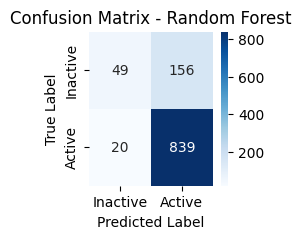

In [62]:
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

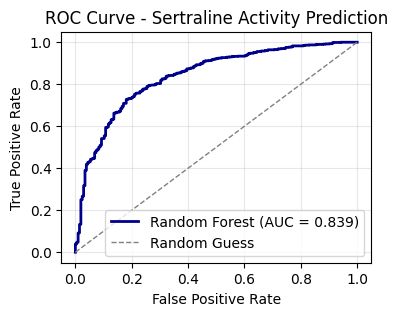

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'Random Forest (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Sertraline Activity Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [64]:
with open("naive_bayes.pkl","wb") as m:
    pickle.dump(model,m)